# External Methods Comparison

Compares three external baseline methods from the literature against our IQL results:

| Method key | Description |
|---|---|
| `pca_iql` | PCA encoder + IQL (linear, no privileged info) |
| `riql` | Robust IQL — no encoder, algorithm-level robustness |
| `denoised_mdp` | Denoised MDP — neural encoder, no privileged info |

**Noise config is auto-derived from environment** — do not edit `ENV_NOISE_DIMS`.

**Cell layout**
- Cell 1 — Imports & project root  
- Cell 2 — Tunable config  
- Cell 3 — Plot style  
- Cell 4 — Method labels, order, palette  
- Step 1 — Load metrics  
- Step 2 — Plot helpers  
- Step 3 — Save tables  
- Step 4 — Generate & save figures

In [12]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Cannot locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    RAW_METRICS_DIR,
    FIGURES_EXTERNAL_DIR,
    TABLES_EXTERNAL_DIR,
)

print(f"PROJECT_ROOT          = {PROJECT_ROOT}")
print(f"RAW_METRICS_DIR       = {RAW_METRICS_DIR}")
print(f"FIGURES_EXTERNAL_DIR  = {FIGURES_EXTERNAL_DIR}")
print(f"TABLES_EXTERNAL_DIR   = {TABLES_EXTERNAL_DIR}")

PROJECT_ROOT          = /home/wyuhan/projects/robust-offline-rl-disentanglement
RAW_METRICS_DIR       = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/raw_metrics
FIGURES_EXTERNAL_DIR  = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/external_methods/figures
TABLES_EXTERNAL_DIR   = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/external_methods/tables


In [13]:
# ============================================================
# Tunable config — modify this cell only
# ============================================================

# External methods to include (comment out those not yet run)
TARGET_METHODS = [
    "pca",             # exp_pca_iql.ipynb      → METHOD = "pca"
    "raw_noisy_riql",  # exp_raw_noisy_riql.ipynb → METHOD = "raw_noisy_riql"
    "denoised_mdp",    # exp_denoised_mdp.ipynb  → METHOD = "denoised_mdp"
]

# Overlay best IQL disentangled methods for comparison
COMPARE_WITH_IQL = True
IQL_REFERENCE_METHODS = [
    "disentangled_barlow",
    "disentangled_dcor",
    "disentangled_hsic",
    "plain",
]

# Environments
TARGET_ENVS = [
    "halfcheetah-medium-v2",
    # "hopper-medium-v2",
    # "ant-medium-v2",
]

TARGET_SEEDS = [1, 2, 3]

# ── Noise config: auto-derived from env — DO NOT EDIT ────────
ENV_NOISE_DIMS = {
    "halfcheetah-medium-v2": [4, 8, 13, 17],
    "hopper-medium-v2":      [3, 6, 8, 11],
    "ant-medium-v2":         [28, 56, 83, 111],
}
NOISE_SCALES = [0.5, 1.0, 1.5, 2.0]
NOISE_TYPE   = "nonlinear"
# ─────────────────────────────────────────────────────────────

SAVE_FIGURES = True
SAVE_TABLES  = True
SHOW_FIGURES = True

In [14]:
sns.set_theme(style="whitegrid", font_scale=1.1)

In [15]:
# External method labels and palette
ext_method_labels = {
    "pca":            "PCA-IQL",
    "raw_noisy_riql": "RIQL",
    "denoised_mdp":   "Denoised MDP",
}

# IQL reference labels
iql_method_labels = {
    "disentangled_barlow": "Barlow (IQL)",
    "disentangled_dcor":   "dCor (IQL)",
    "disentangled_hsic":   "HSIC (IQL)",
    "plain":               "Plain (IQL)",
    "true_only":           "No Noise (IQL)",
}

all_method_labels = {**ext_method_labels, **iql_method_labels}

# Display order in all plots: external first, then IQL reference
global_order = [
    "PCA-IQL", "RIQL", "Denoised MDP",
    "Barlow (IQL)", "dCor (IQL)", "HSIC (IQL)",
    "Plain (IQL)", "No Noise (IQL)",
]

palette = {
    # External methods — distinct colors
    "PCA-IQL":        "#1abc9c",
    "RIQL":           "#f39c12",
    "Denoised MDP":   "#9b59b6",
    # IQL reference — lighter shades
    "Barlow (IQL)":   "#f1948a",
    "dCor (IQL)":     "#bb8fce",
    "HSIC (IQL)":     "#e59866",
    "Plain (IQL)":    "#7fb3d3",
    "No Noise (IQL)": "#808b96",
}

## Step 1 — Load metrics

In [16]:
def scale_to_tag(v: float) -> str:
    return str(v).replace(".", "p")


def _infer_method(norm: str, keys) -> str:
    for k in sorted(keys, key=len, reverse=True):
        if f"/{k}/" in norm:
            return k
    return ""


def _infer_env(path: Path, envs) -> str:
    parts = set(path.parts)
    for e in envs:
        if e in parts:
            return e
    return ""


def load_metrics(
    raw_metrics_dir: Path,
    ext_methods,
    iql_methods,
    target_seeds,
    target_envs,
    env_noise_dims,
    noise_scales,
    noise_type,
):
    """
    Returns
    -------
    df_noisy  : records with noise_dim / noise_scale
    df_oracle : records without noise params — true_only only
    """
    all_keys = set(ext_methods) | set(iql_methods)

    noisy, oracle = [], []
    seen = set()

    for fp in raw_metrics_dir.rglob("*.json"):
        key = str(fp.resolve())
        if key in seen:
            continue
        seen.add(key)

        try:
            data = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            continue

        score = data.get("normalized_score")
        if score is None:
            continue

        norm = str(fp.parent).replace("\\", "/")
        cfg  = data.get("data_config", {})

        method = (
            data.get("method") or data.get("group")
            or _infer_method(norm, all_keys)
        )
        if method not in all_keys:
            continue

        env = (
            data.get("env_name") or data.get("env")
            or cfg.get("env_name") or _infer_env(fp, target_envs)
        )
        if env not in target_envs:
            continue

        seed = data.get("seed", cfg.get("seed"))
        if seed is None:
            m = re.search(r"seed_?(\d+)", norm, re.IGNORECASE)
            seed = int(m.group(1)) if m else None
        else:
            seed = int(seed)
        if seed not in target_seeds:
            continue

        nd    = data.get("noise_dim",   cfg.get("noise_dim"))
        ns    = data.get("noise_scale", cfg.get("noise_scale"))
        ntype = data.get("noise_type",  cfg.get("noise_type"))

        # Oracle: only true_only (no noise by design).
        # Other methods missing noise_type are legacy files — skip.
        if nd is None or ns is None or ntype is None:
            if method == "true_only":
                oracle.append({"Method": method, "Env": env,
                               "Seed": seed, "Score": float(score)})
            continue

        if ntype != noise_type:
            continue
        env_dims = env_noise_dims.get(env, [])
        if int(nd) not in env_dims:
            continue
        if float(ns) not in noise_scales:
            continue

        noisy.append({
            "Method": method, "Env": env,
            "Dim": int(nd), "Scale": float(ns),
            "Type": ntype, "Seed": seed,
            "Score": float(score),
        })

    df_noisy  = pd.DataFrame(noisy)
    df_oracle = (
        pd.DataFrame(oracle)
        .drop_duplicates(subset=["Method", "Env", "Seed"], keep="first")
        .reset_index(drop=True)
        if oracle else pd.DataFrame()
    )
    return df_noisy, df_oracle

In [17]:
iql_ref_keys = IQL_REFERENCE_METHODS if COMPARE_WITH_IQL else []

df_noisy, df_oracle = load_metrics(
    raw_metrics_dir=RAW_METRICS_DIR,
    ext_methods=TARGET_METHODS,
    iql_methods=iql_ref_keys + ["true_only"],
    target_seeds=TARGET_SEEDS,
    target_envs=TARGET_ENVS,
    env_noise_dims=ENV_NOISE_DIMS,
    noise_scales=NOISE_SCALES,
    noise_type=NOISE_TYPE,
)

seed_tag = "_".join(str(s) for s in sorted(TARGET_SEEDS))

print(f"Noise-sweep records : {len(df_noisy)}")
print(f"Oracle records      : {len(df_oracle)}")
if not df_noisy.empty:
    print("Methods found:", sorted(df_noisy['Method'].unique()))
    print("Envs found:   ", sorted(df_noisy['Env'].unique()))
if not df_oracle.empty:
    print("Oracle methods:", sorted(df_oracle['Method'].unique()))

df_noisy.head()

Noise-sweep records : 336
Oracle records      : 3
Methods found: ['denoised_mdp', 'disentangled_barlow', 'disentangled_dcor', 'disentangled_hsic', 'pca', 'plain', 'raw_noisy_riql']
Envs found:    ['halfcheetah-medium-v2']
Oracle methods: ['true_only']


,Method,Env,Dim,Scale,Type,Seed,Score
0,disentangled_dcor,halfcheetah-medium-v2,8,1.5,nonlinear,1,36.931707
1,disentangled_dcor,halfcheetah-medium-v2,8,1.5,nonlinear,3,38.819977
2,disentangled_dcor,halfcheetah-medium-v2,8,1.5,nonlinear,2,36.610604
3,disentangled_dcor,halfcheetah-medium-v2,13,1.0,nonlinear,1,36.597010
4,disentangled_dcor,halfcheetah-medium-v2,13,1.0,nonlinear,3,36.297852


## Step 2 — Plot helpers

In [18]:
def _add_labels(df, label_map):
    df = df.copy()
    df["Label"] = df["Method"].map(label_map)
    return df


def _present_order(df, global_order):
    present = set(df["Label"].dropna())
    return [m for m in global_order if m in present]


def build_oracle_lines(df_oracle, env, all_method_labels, palette):
    """Return {display_label: mean_score} for dashed reference lines."""
    if df_oracle.empty:
        return {}
    result = {}
    for method, grp in df_oracle[df_oracle["Env"] == env].groupby("Method"):
        label = all_method_labels.get(method)
        if label:
            result[label] = float(grp["Score"].mean())
    return result


def plot_bar(
    sub_df, x_col, x_label, title,
    all_method_labels, global_order, palette,
    iql_lines=None, oracle_lines=None,
    save_path=None, show=True,
):
    """Bar chart. IQL reference as dashed hlines; true_only oracle as dotted hline."""
    if sub_df.empty:
        return
    plot_df = _add_labels(sub_df, all_method_labels)
    order   = _present_order(plot_df, global_order)
    plot_df["Label"] = pd.Categorical(plot_df["Label"], categories=order, ordered=True)

    n_x = len(plot_df[x_col].unique())
    fig, ax = plt.subplots(figsize=(max(8, n_x * len(order) * 0.5), 6))
    sns.barplot(
        data=plot_df, x=x_col, y="Score", hue="Label",
        palette=palette, edgecolor="black", linewidth=1.2,
        capsize=0.05, ax=ax,
    )
    for patch in ax.patches:
        h = patch.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(f"{h:.1f}",
                        (patch.get_x() + patch.get_width() / 2, h),
                        ha="center", va="bottom",
                        xytext=(0, 4), textcoords="offset points",
                        fontsize=8, fontweight="bold", rotation=90)

    if iql_lines:
        for lbl, val in iql_lines.items():
            ax.axhline(val, linestyle="--", linewidth=1.5,
                       color=palette.get(lbl, "gray"), label=lbl, alpha=0.85)
    if oracle_lines:
        for lbl, val in oracle_lines.items():
            ax.axhline(val, linestyle=":", linewidth=1.8,
                       color=palette.get(lbl, "#2c3e50"), label=lbl, alpha=0.85)

    ax.legend(title="Method", fontsize=9, title_fontsize=10,
              bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Normalized D4RL Score", fontsize=12)
    scores = plot_df["Score"][plot_df["Score"] > 0]
    if not scores.empty:
        ax.set_ylim(max(0, scores.min() - 10), plot_df["Score"].max() + 15)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show() if show else plt.close()


def plot_line(
    sub_df, x_col, x_label, title,
    all_method_labels, global_order, palette,
    iql_lines=None, oracle_lines=None,
    save_path=None, show=True,
):
    """Line chart. IQL reference as dashed lines; true_only oracle as dotted hline."""
    if sub_df.empty:
        return
    plot_df = _add_labels(sub_df, all_method_labels)
    order   = _present_order(plot_df, global_order)

    stats = (
        plot_df.groupby(["Label", x_col])["Score"]
        .agg(["mean", "std"]).reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for label in order:
        cur = stats[stats["Label"] == label].sort_values(x_col)
        if cur.empty:
            continue
        ls = "--" if "(IQL)" in label else "-"
        ax.errorbar(
            cur[x_col], cur["mean"], yerr=cur["std"].fillna(0),
            marker="o", capsize=4, linewidth=2, markersize=5,
            linestyle=ls, label=label,
            color=palette.get(label, "#aaaaaa"),
        )

    if iql_lines:
        for lbl, val in iql_lines.items():
            ax.axhline(val, linestyle="--", linewidth=1.5,
                       color=palette.get(lbl, "gray"), label=lbl, alpha=0.85)
    if oracle_lines:
        for lbl, val in oracle_lines.items():
            ax.axhline(val, linestyle=":", linewidth=1.8,
                       color=palette.get(lbl, "#2c3e50"), label=lbl, alpha=0.85)

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Normalized D4RL Score", fontsize=12)
    ax.set_xticks(sorted(stats[x_col].unique()))
    means = stats["mean"]
    if not means.empty:
        ax.set_ylim(max(0, means[means > 0].min() - 10), means.max() + 15)
    ax.legend(title="Method", fontsize=9, title_fontsize=10,
              bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show() if show else plt.close()

## Step 3 — Save tables

In [19]:
def save_tables(df_noisy, df_oracle, table_dir: Path, seed_tag):
    table_dir.mkdir(parents=True, exist_ok=True)

    if not df_noisy.empty:
        p = table_dir / f"records_external_seeds_{seed_tag}.csv"
        df_noisy.to_csv(p, index=False)
        print(f"Saved records  → {p}")

        summary = (
            df_noisy.groupby(["Method", "Env", "Dim", "Scale", "Type"])["Score"]
            .agg(mean="mean", std="std", n="count")
            .reset_index()
        )
        p = table_dir / f"summary_external_seeds_{seed_tag}.csv"
        summary.to_csv(p, index=False)
        print(f"Saved summary  → {p}")

    if not df_oracle.empty:
        p = table_dir / f"oracle_seeds_{seed_tag}.csv"
        df_oracle.to_csv(p, index=False)
        print(f"Saved oracle   → {p}")

In [20]:
if SAVE_TABLES:
    for env in TARGET_ENVS:
        d_n = df_noisy[df_noisy["Env"] == env]   if not df_noisy.empty  else pd.DataFrame()
        d_o = df_oracle[df_oracle["Env"] == env]  if not df_oracle.empty else pd.DataFrame()
        if d_n.empty and d_o.empty:
            print(f"[WARN] No data for {env}, skipping.")
            continue
        save_tables(d_n, d_o, TABLES_EXTERNAL_DIR / env, seed_tag)
else:
    print("Table export disabled.")

Saved records  → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/external_methods/tables/halfcheetah-medium-v2/records_external_seeds_1_2_3.csv
Saved summary  → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/external_methods/tables/halfcheetah-medium-v2/summary_external_seeds_1_2_3.csv
Saved oracle   → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/external_methods/tables/halfcheetah-medium-v2/oracle_seeds_1_2_3.csv


## Step 4 — Generate & save figures

In [21]:
def generate_figures(
    df_noisy, df_oracle, env,
    env_noise_dims, noise_scales,
    fig_dir: Path,
    all_method_labels, global_order, palette,
    save=True, show=True,
):
    target_dims = env_noise_dims.get(env, [])

    # Separate IQL sweep lines vs true_only oracle
    iql_lines    = {}
    oracle_lines = {}
    if not df_oracle.empty:
        for method, grp in df_oracle[df_oracle["Env"] == env].groupby("Method"):
            label = all_method_labels.get(method)
            if label is None:
                continue
            val = float(grp["Score"].mean())
            if method == "true_only":
                oracle_lines[label] = val
            else:
                iql_lines[label] = val

    bar_dir  = fig_dir / "bar"
    line_dir = fig_dir / "line"

    # Scale sweep: fix dim, x-axis = scale
    for dim in target_dims:
        sub = df_noisy[df_noisy["Dim"] == dim]
        if sub.empty:
            continue
        title = f"Scale Sweep  |  noise_dim={dim}  |  external methods"
        plot_bar(
            sub, "Scale", "Noise Scale", title,
            all_method_labels, global_order, palette,
            iql_lines=iql_lines, oracle_lines=oracle_lines,
            save_path=bar_dir / f"scale_sweep_dim_{dim}.png" if save else None,
            show=show,
        )
        plot_line(
            sub, "Scale", "Noise Scale", title,
            all_method_labels, global_order, palette,
            iql_lines=iql_lines, oracle_lines=oracle_lines,
            save_path=line_dir / f"scale_curve_dim_{dim}.png" if save else None,
            show=show,
        )

    # Dim sweep: fix scale, x-axis = dim
    for scale in noise_scales:
        sub = df_noisy[df_noisy["Scale"] == scale]
        if sub.empty:
            continue
        stag  = scale_to_tag(scale)
        title = f"Dim Sweep  |  noise_scale={scale}  |  external methods"
        plot_bar(
            sub, "Dim", "Noise Dimension", title,
            all_method_labels, global_order, palette,
            iql_lines=iql_lines, oracle_lines=oracle_lines,
            save_path=bar_dir / f"dim_sweep_scale_{stag}.png" if save else None,
            show=show,
        )
        plot_line(
            sub, "Dim", "Noise Dimension", title,
            all_method_labels, global_order, palette,
            iql_lines=iql_lines, oracle_lines=oracle_lines,
            save_path=line_dir / f"dim_curve_scale_{stag}.png" if save else None,
            show=show,
        )


--- halfcheetah-medium-v2 ---


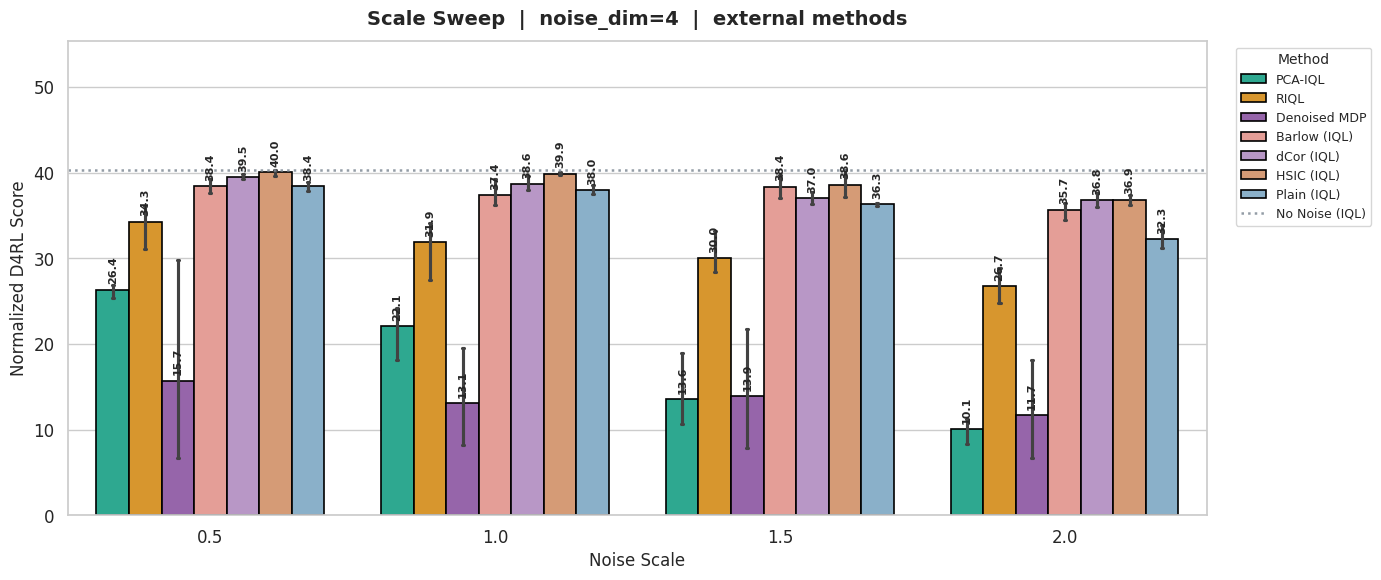

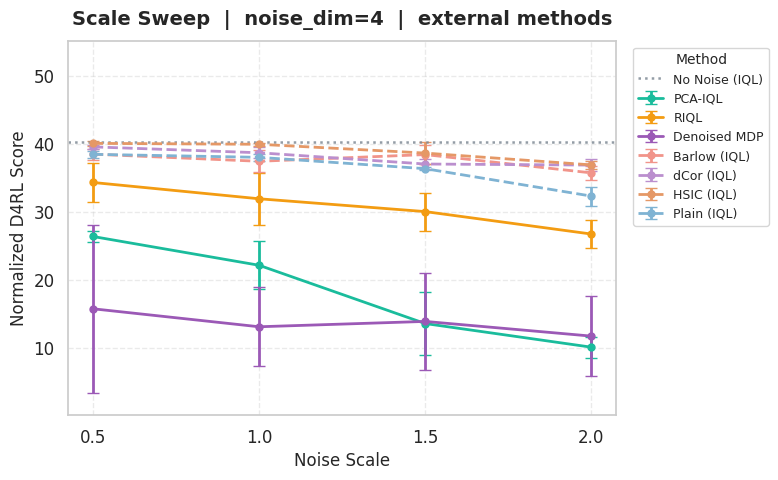

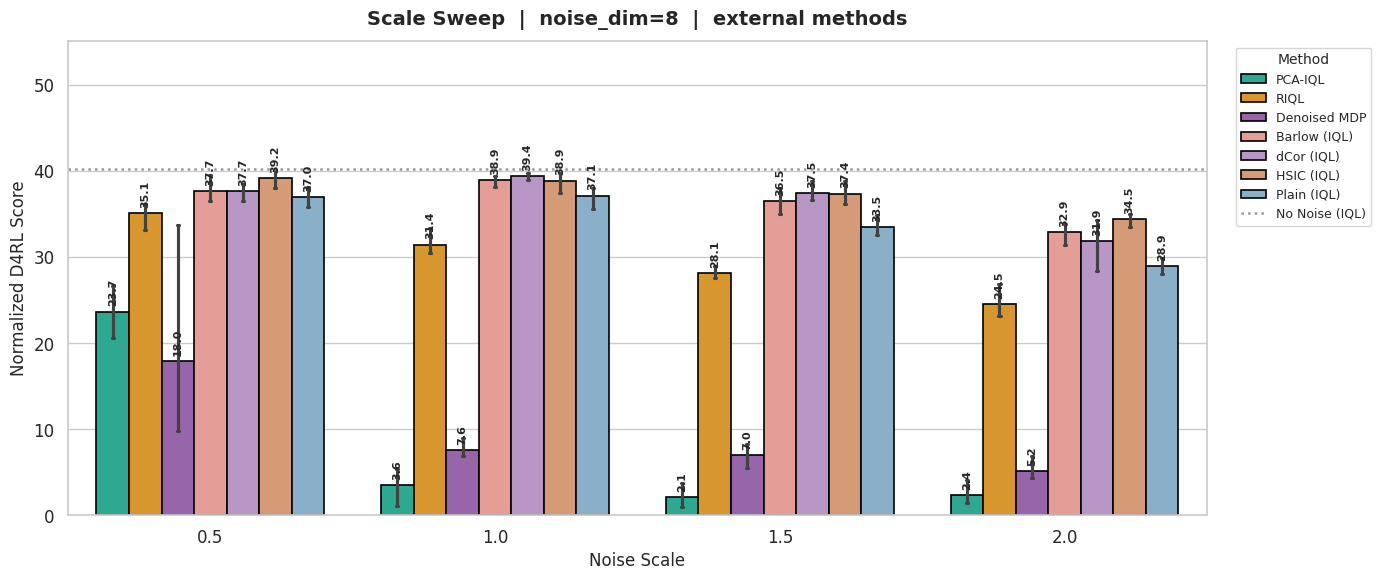

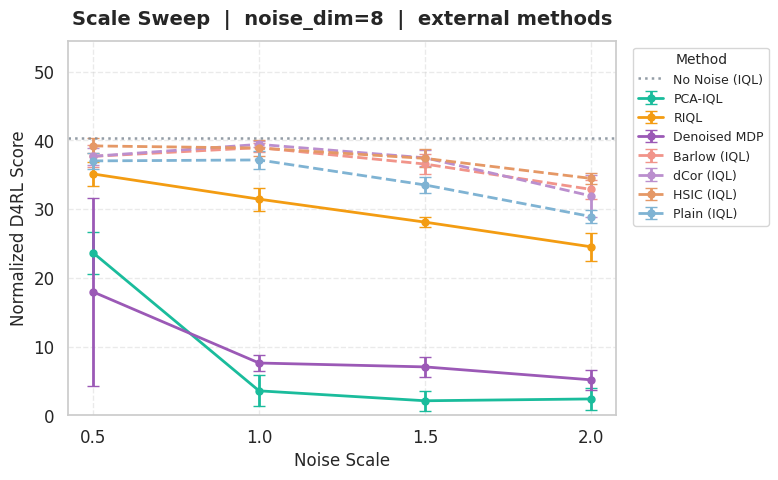

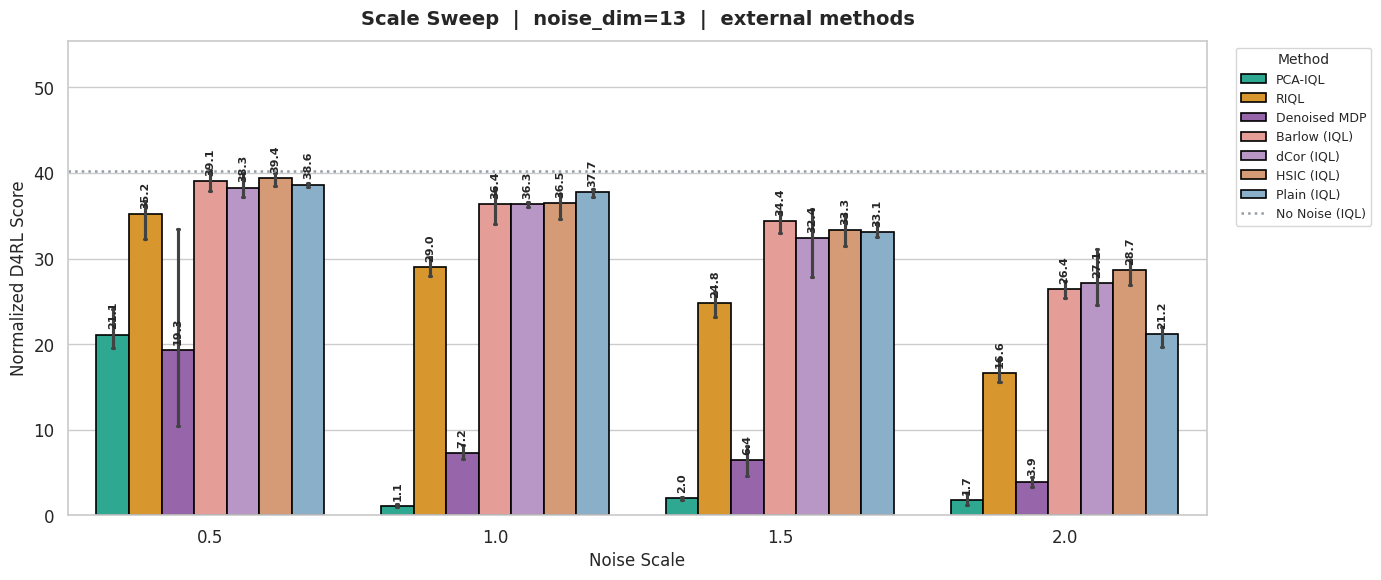

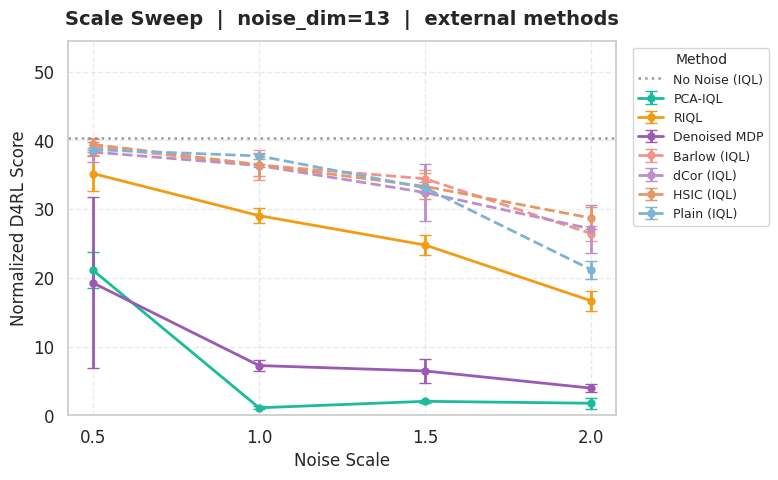

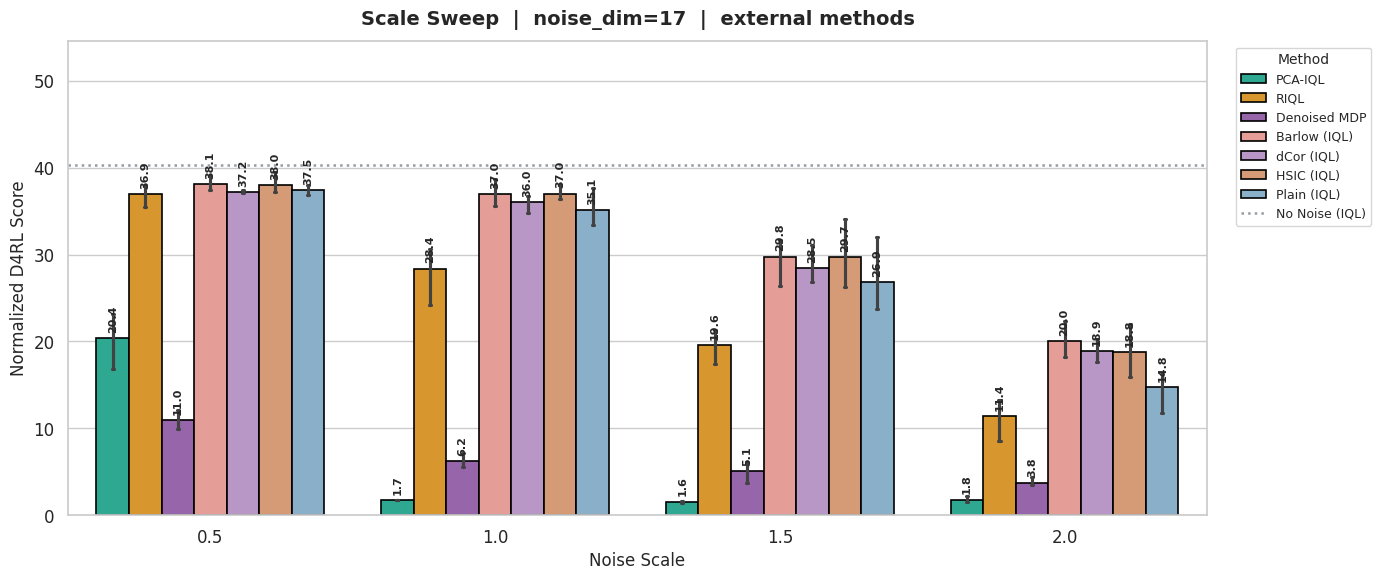

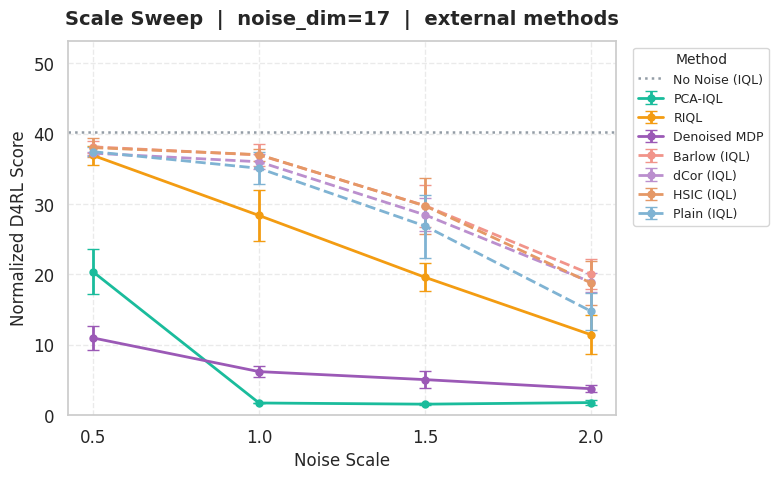

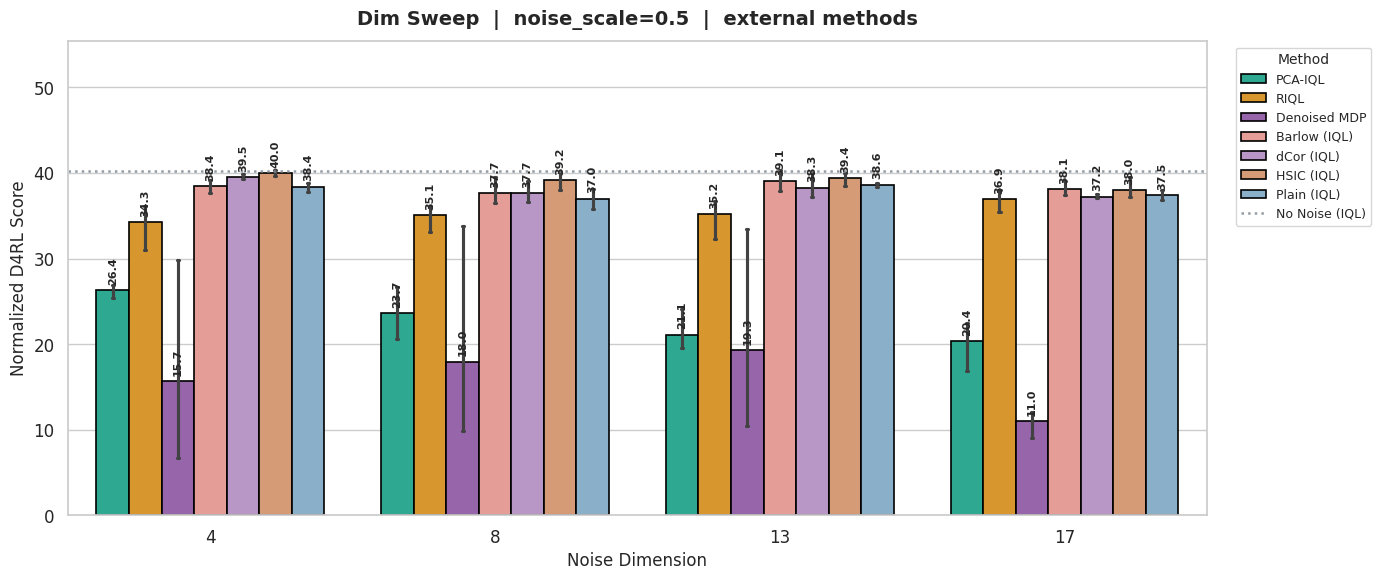

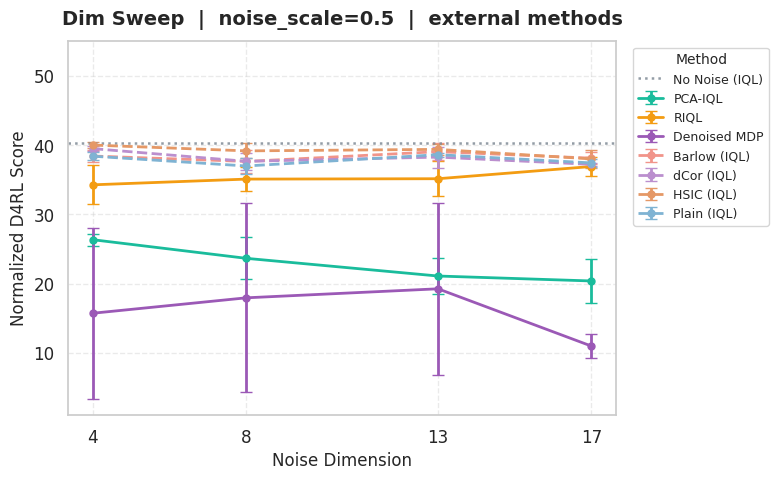

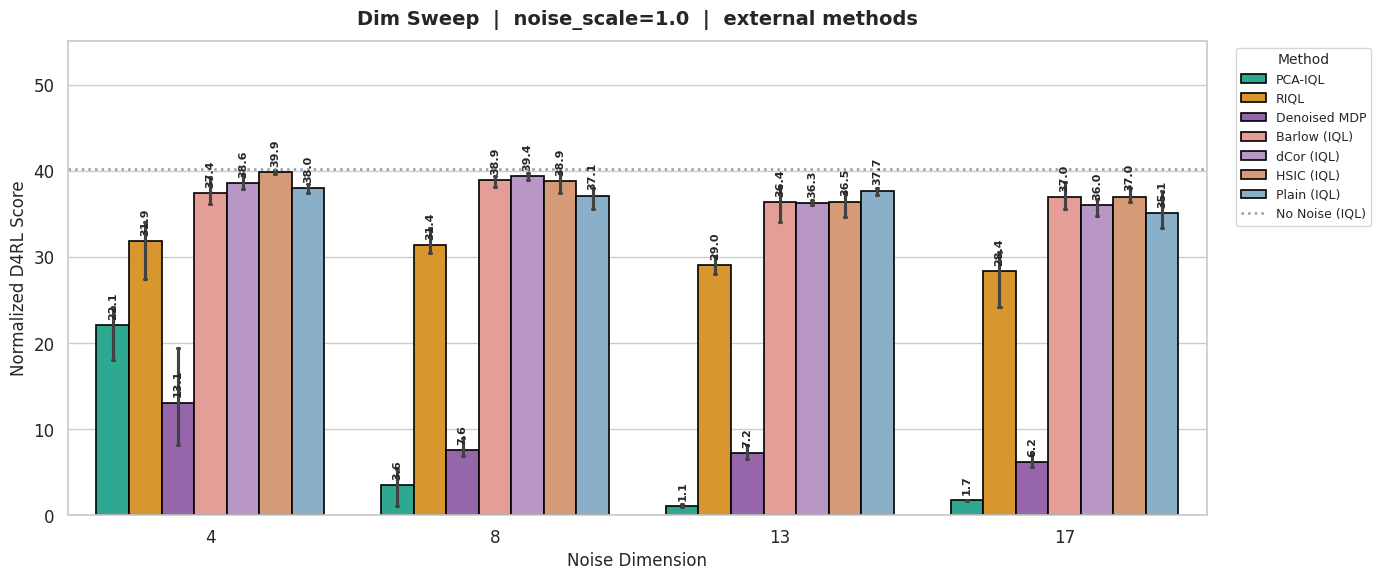

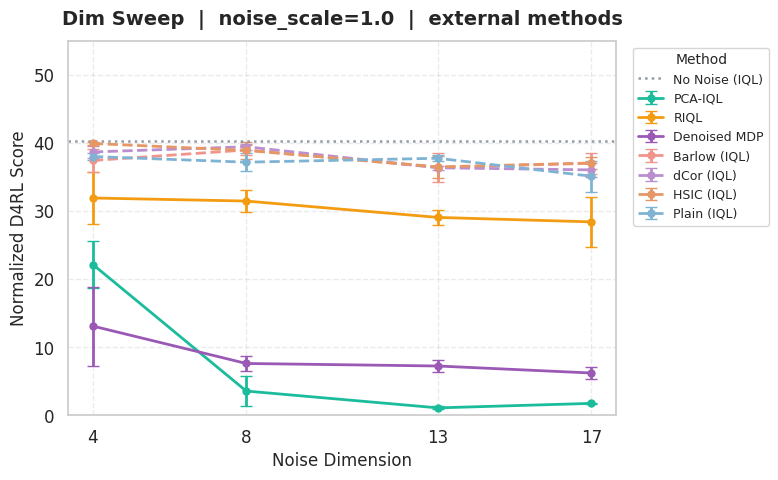

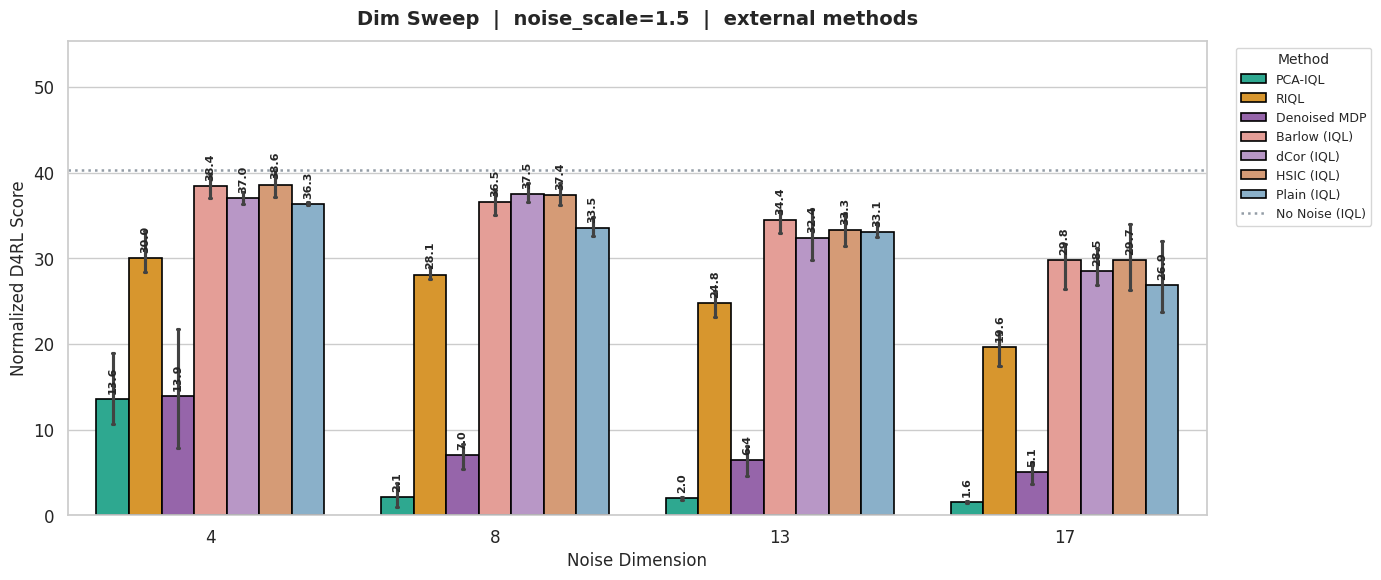

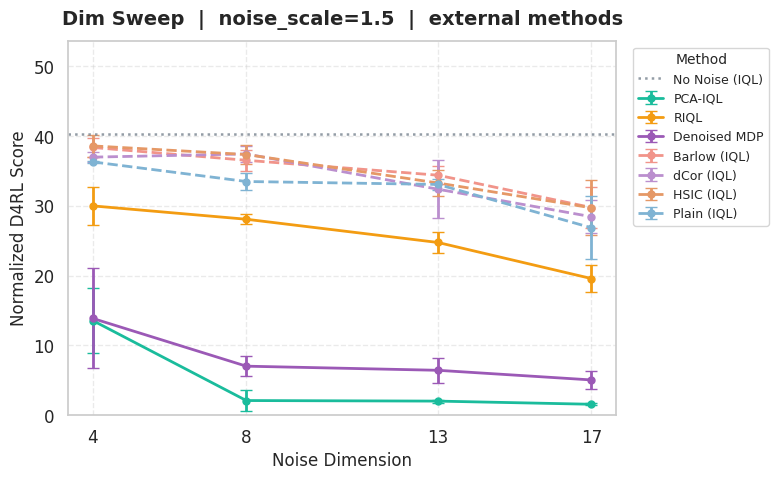

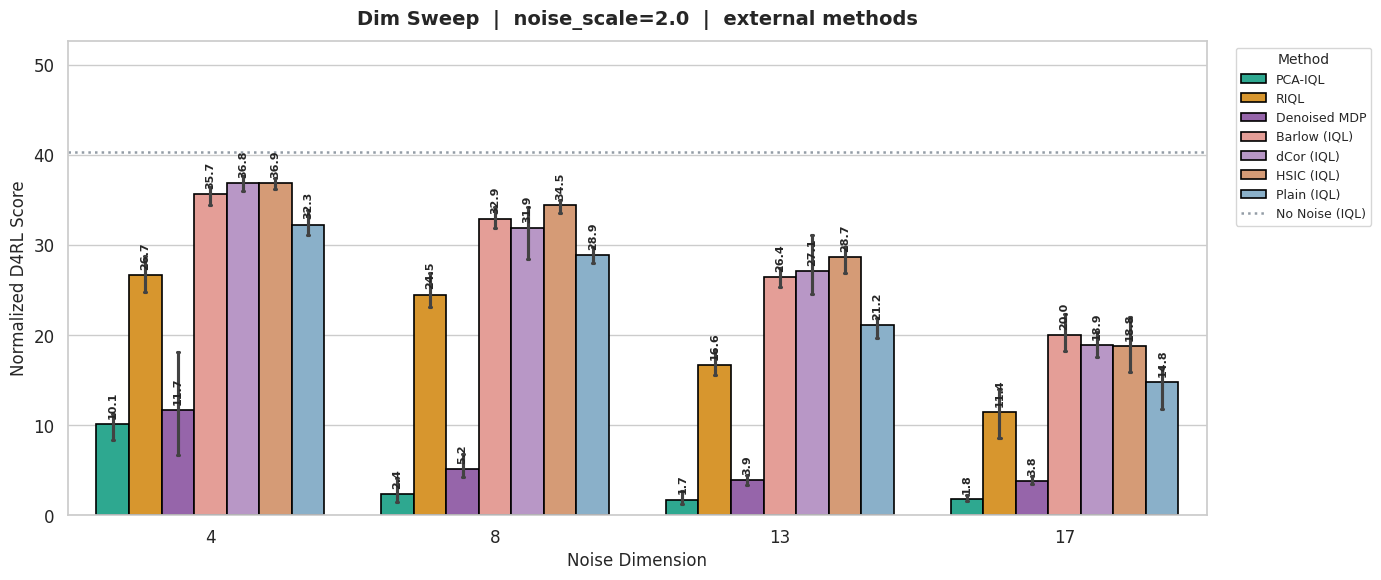

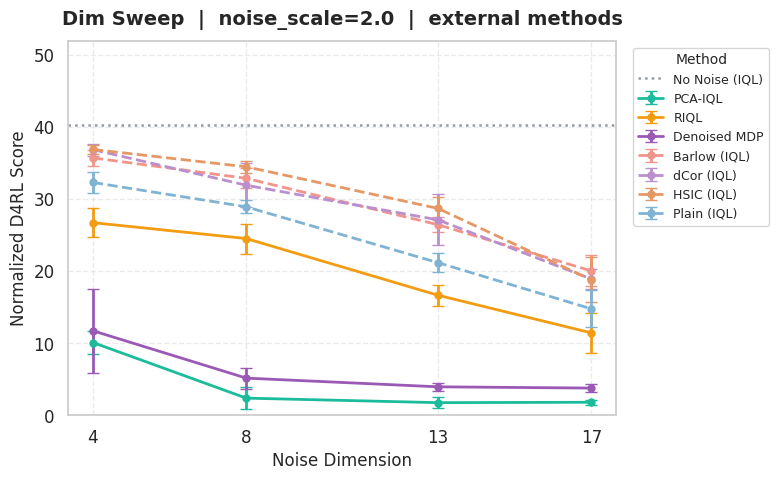

In [22]:
for env in TARGET_ENVS:
    d_n = df_noisy[df_noisy["Env"] == env]   if not df_noisy.empty  else pd.DataFrame()
    d_o = df_oracle[df_oracle["Env"] == env]  if not df_oracle.empty else pd.DataFrame()

    if d_n.empty:
        print(f"[WARN] No noise-sweep data for {env} — "
              f"external method results not yet available.")
        continue

    fig_dir = FIGURES_EXTERNAL_DIR / env
    print(f"\n--- {env} ---")
    generate_figures(
        df_noisy=d_n,
        df_oracle=d_o,
        env=env,
        env_noise_dims=ENV_NOISE_DIMS,
        noise_scales=NOISE_SCALES,
        fig_dir=fig_dir,
        all_method_labels=all_method_labels,
        global_order=global_order,
        palette=palette,
        save=SAVE_FIGURES,
        show=SHOW_FIGURES,
    )